In [1]:
%load_ext autoreload
%autoreload 2
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import cartopy.feature as cfeature
import warnings
import cmocean as cm
warnings.filterwarnings('ignore')
import xesmf as xe

In [2]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='05:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=14)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 04:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/bin/python -m distributed.cli.dask_worker tcp://172.16.3.132:40738 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.132:40738,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
def get_latitude_average(ds, lats, grid, add_depth=False, depth_name="depth"):
    Z_l = grid.axes["Z"].coords["center"]
    Z_l_prefix = Z_l.split("_")[0]

    wet = ds["wet"].fillna(0.0)
    area = ds["areacello"].fillna(0.0)
    thk = ds["thkcello"].fillna(0.0)
    vol = area * thk

    vars_on_yh = [
        v for v in ds.data_vars
        if v != "thkcello" and {"xh", "yh"}.issubset(ds[v].dims)
    ]
    ds_var = ds[vars_on_yh]

    if add_depth:
        if depth_name is not None and depth_name in ds:
            z = check_depth_sign(ds[depth_name])
        else:
            return 

    outs = []
    for lat0 in lats:
        mask_south_yq = ds["geolat_v"] <= lat0
        boundary_mask_yh = grid.diff(mask_south_yq.astype("float32"), axis="Y", boundary="fill") < 0
        valid_bnd = boundary_mask_yh & (wet > 0.0)

        layer_area = vol.where(valid_bnd).fillna(0.0)
        layer_area = layer_area.where(layer_area > 0)
        tot_layer_area = layer_area.sum(dim=["xh", "yh"], skipna=True).fillna(0.0)

        var_integrated = (ds_var * layer_area).sum(dim=["xh", "yh"], skipna=True)
        ds_avg_lat = var_integrated / tot_layer_area

        if add_depth:
            z_weighted = (z * layer_area).sum(dim=["xh", "yh"], skipna=True)
            z_avg = z_weighted / tot_layer_area
            ds_avg_lat = ds_avg_lat.assign_coords({depth_name: z_avg})

        ds_avg_lat = ds_avg_lat.expand_dims(lat=[lat0])
        outs.append(ds_avg_lat)

    return xr.concat(outs, dim="lat")

In [4]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]

In [5]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.sel(year = slice(1850, 2099))


ds_ctrl= xr.open_mfdataset(full_depth_files[0], 
                            data_vars="minimal",
                            coords="minimal",
                            compat="override",
                           parallel=True, 
                           preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:],                             
                              data_vars="minimal",
                            coords="minimal",
                            compat="override",
                              parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")

ds.coords["z_i"] = np.array([0.000e+00, 5.000e+00, 1.500e+01, 2.500e+01, 4.000e+01, 6.250e+01,
       8.750e+01, 1.125e+02, 1.375e+02, 1.750e+02, 2.250e+02, 2.750e+02,
       3.500e+02, 4.500e+02, 5.500e+02, 6.500e+02, 7.500e+02, 8.500e+02,
       9.500e+02, 1.050e+03, 1.150e+03, 1.250e+03, 1.350e+03, 1.450e+03,
       1.625e+03, 1.875e+03, 2.250e+03, 2.750e+03, 3.250e+03, 3.750e+03,
       4.250e+03, 4.750e+03, 5.250e+03, 5.750e+03, 6.250e+03, 6.750e+03])

ds_sigma2 = xr.open_mfdataset("/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/CM4Xp25_budgets_sigma2_1750-1754.zarr", engine = "zarr")
ds.coords["sigma2_i"] = ds_sigma2.sigma2_i.values
ds.coords["sigma2_l"] = ds_sigma2.sigma2_l.values
ds["depth"] = approximate_z_top_down(ds, dim=f"z")

ds = ds.drop_vars(["sigma2", "volcello"]).rename({"sigma2_offline":"sigma2"})
# ds = ds.drop_vars(["sigma2_offline", "volcello"])

In [6]:
import cmip_basins.cmip6 as cmip6_basins
from cmip_basins.basins import generate_basin_codes

grid = CM4Xutils.ds_to_grid(ds.drop_vars("depth"), Zprefix = "z_")
grid._ds["sigma2"] = ds["sigma2"].ffill("z_l").bfill("z_l")
ds_remapped = CM4Xutils.remap_vertical_coord("sigma2", grid._ds.chunk({"z_l": -1}), grid)
ds_remapped["depth"] = -approximate_z_top_down(ds_remapped.fillna(0.0), dim=f"sigma2")


codes = generate_basin_codes(ds_remapped, lon="geolon", lat="geolat", persian=True, style="cmip6")
c_mask = 1.0 * codes.isin([1, 3, 5, 10, 11]).where(ds_remapped.wet > 0.0).compute()
c_mask = c_mask.where(c_mask > 0.0)

grid = CM4Xutils.ds_to_grid(ds_remapped)

for v in ["thkcello", "wet"]:
    # ds_remapped[v] = ds_remapped[v].where(c_mask > 0.0)
    ds_remapped[v] = c_mask * ds_remapped[v]

ds_remapped["depth"] = ds_remapped["depth"].where(ds_remapped["thkcello"] > 0.0)
ds_remapped = ds_remapped.where(ds_remapped["depth"] > 100.0) #remove the mixed layer 

Inferring Z grid coordinate: density `sigma2`


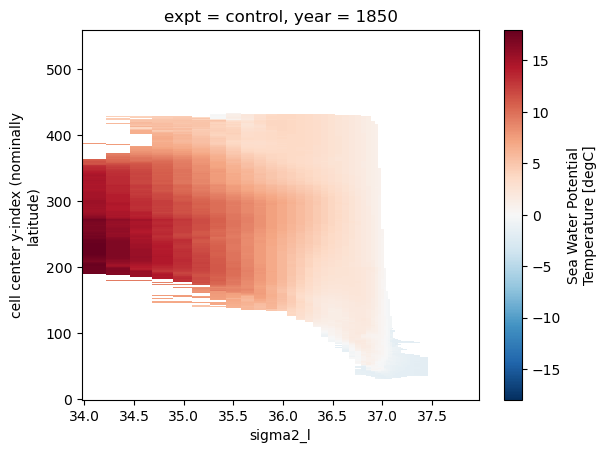

In [7]:
ds_remapped["thetao"].where(ds_remapped["thkcello"] > 0.0).isel(expt = 0, year = 0).mean("xh", skipna = True).sel(sigma2_l = slice(34, 38)).plot()

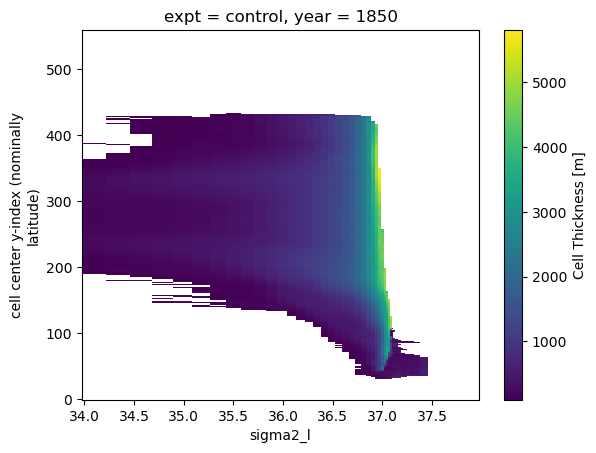

In [8]:
ds_remapped["depth"].isel(expt = 0, year = 0).mean("xh", skipna = True).sel(sigma2_l = slice(34, 38)).plot()

(34.0, 38.0)

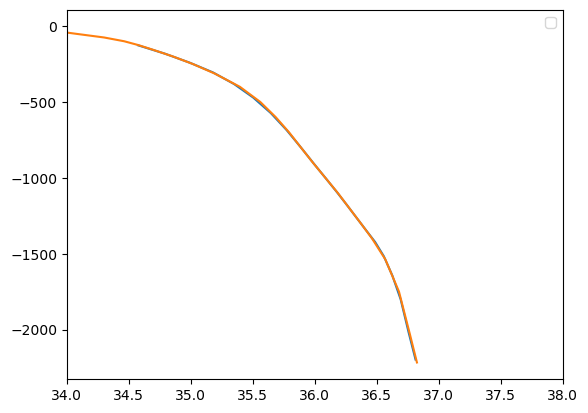

In [9]:
plt.plot(ds_remapped.sigma2_l, -ds_remapped["depth"].isel(year = 0, expt = 0, yh = 200, xh = 200))
plt.plot(ds["sigma2"].isel(year = 0, expt = 0, yh = 200, xh = 200), ds["depth"].isel(year = 0, expt = 0, yh = 200, xh = 200))

plt.legend()
plt.xlim(34, 38)

(34.0, 38.0)

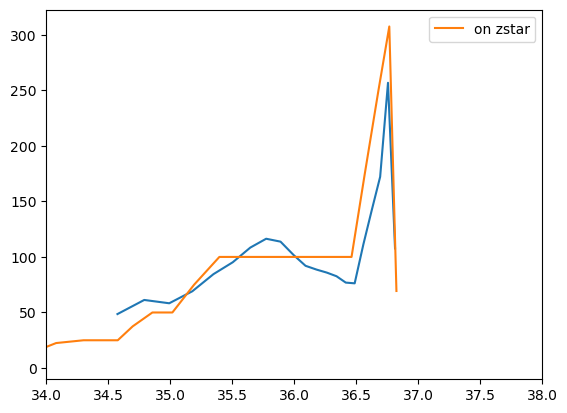

In [10]:
plt.plot(ds_remapped.sigma2_l, ds_remapped["thkcello"].isel(year = 0, expt = 0, yh = 200, xh = 200))
plt.plot(ds["sigma2"].isel(year = 0, expt = 0, yh = 200, xh = 200), ds["thkcello"].isel(year = 0, expt = 0, yh = 200, xh = 200), label = "on zstar")
plt.legend()
plt.xlim(34, 38)

(34.0, 38.0)

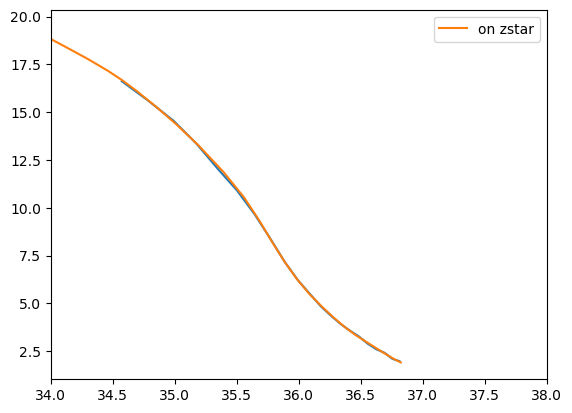

In [11]:
plt.plot(ds_remapped.sigma2_l, ds_remapped["thetao"].isel(year = 0, expt = 0, yh = 200, xh = 200))
plt.plot(ds["sigma2"].isel(year = 0, expt = 0, yh = 200, xh = 200), ds["thetao"].isel(year = 0, expt = 0, yh = 200, xh = 200), label = "on zstar")
plt.legend()
plt.xlim(34, 38)

In [ ]:
from tqdm.auto import tqdm

lats = np.arange(-75, 60, 1)
outs = []
step = 10
years = ds.sizes["year"]

for i in tqdm(range(0, years, step), desc="Year blocks"):
    ds_t = ds_remapped.isel(year=slice(i, i + step))

    tmp = get_latitude_average(ds_t.chunk({"sigma2_l": -1, "year":1, "xh":-1, "yh":-1}), lats, grid, add_depth=True, depth_name="depth")
    outs.append(tmp.compute())

Year blocks:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
outs[0].depth.isel(year = 0, expt = 0).sel(sigma2_l = slice(34, 38)).plot()

In [ ]:
ds_zon_ts_ds = xr.concat(outs, dim="year")

In [ ]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"IndoPac_Tracer_Avg_on_sigma2.zarr"
ds_zon_ts_ds.to_zarr(savename, compute = True, mode = "w")

In [ ]:
ds_zon_ts_ds.isel(year = -1, expt = 0)["cfc11"].sel(sigma2_l = slice(36, 38)).plot()